# Pipeline ELT con MongoDB, Spark, Jupyter y Matplotlib

## Objetivo
Construir un pipeline ELT a partir de la colección `movieDetails` de la base `video`, utilizando MongoDB como origen y destino, PySpark para el procesamiento, JupyterLab como entorno de trabajo y Matplotlib para visualización.

En este notebook se realiza:
- Conexión a MongoDB desde Spark,
- Exploración inicial del dataset,
- Identificación de problemas de calidad,
- Construcción de una colección Silver,
- Construcción de tres colecciones Gold,
- Visualización de resultados,
- Comparación de procesamiento con 1 y 4 particiones.

## Creacion de sesión de Spark

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ELT_MovieDetails") \
    .master("local[*]") \
    .config("spark.ui.port", "4040") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .config("spark.mongodb.read.connection.uri", "mongodb://host.docker.internal:27017/") \
    .config("spark.mongodb.write.connection.uri", "mongodb://host.docker.internal:27017/") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)

Spark version: 3.5.1
Spark UI: http://7957084bdcda:4040


## Carga de datos desde MongoDB

Se carga la colección original `video.movieDetails` desde MongoDB utilizando el conector de Spark para MongoDB.

In [4]:
df = spark.read \
    .format("mongodb") \
    .option("database", "video") \
    .option("collection", "movieDetails") \
    .load()

print("Total registros:", df.count())
df.show(5, truncate=False)
df.printSchema()

Total registros: 2299
+------------------------+-------------------------------------------------------------------+--------------------------------------------------------------------+-------------------+---------------------------+---------------------------+--------------------------+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------+-------+-------+---------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-------------------------------------------------------------------------------------+------+
|_id                     |actors              

## Exploración inicial

En esta etapa se revisa el esquema, las columnas disponibles, la cantidad de valores nulos y la existencia de duplicados por identificador.

In [5]:
df.columns

['_id',
 'actors',
 'awards',
 'countries',
 'director',
 'genres',
 'imdb',
 'metacritic',
 'plot',
 'poster',
 'rated',
 'runtime',
 'title',
 'tomato',
 'type',
 'writers',
 'year']

In [6]:
from pyspark.sql.functions import col, sum as spark_sum

nulls = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

nulls.show(truncate=False)

+---+------+------+---------+--------+------+----+----------+----+------+-----+-------+-----+------+----+-------+----+
|_id|actors|awards|countries|director|genres|imdb|metacritic|plot|poster|rated|runtime|title|tomato|type|writers|year|
+---+------+------+---------+--------+------+----+----------+----+------+-----+-------+-----+------+----+-------+----+
|0  |4     |5     |4        |186     |4     |4   |1923      |749 |1256  |1603 |436    |2    |1937  |4   |4      |4   |
+---+------+------+---------+--------+------+----+----------+----+------+-----+-------+-----+------+----+-------+----+



In [7]:
print("Total registros:", df.count())
print("IDs distintos:", df.select("_id").distinct().count())

Total registros: 2299
IDs distintos: 2299


## Observaciones de exploración

Los campos más útiles para análisis en este trabajo fueron `title`, `year`, `genres`, `runtime` e `imdb.rating`, porque permiten construir comparaciones por género, análisis temporales y visualizaciones sobre duración y calificación.

La colección contiene 2299 registros y no presenta duplicados por `_id`, ya que la cantidad total de registros coincide con la cantidad de identificadores distintos.

También se observan campos anidados como `imdb`, `tomato` y `awards`, además de arreglos como `genres`, `actors`, `countries` y `writers`. Esto hace necesario tratar adecuadamente la estructura del dataset en Spark.

En cuanto a calidad de datos, se identificaron valores nulos en variables importantes como `imdb`, `runtime`, `title`, `plot`, `rated` y `metacritic`. Estos faltantes afectan directamente la posibilidad de realizar análisis consistentes por género, año, duración y calificación.

A partir de la exploración surgieron oportunidades claras de análisis sobre rating promedio por género, evolución temporal de la cantidad de películas y duración promedio por categoría.

## Criterio de limpieza

Esta decisión mejora principalmente la completitud y la consistencia del dataset para fines analíticos, ya que evita construir agregaciones sobre registros con información esencial ausente.

Se decidió conservar únicamente los registros que tuvieran valores no nulos en `title`, `year`, `genres` e `imdb.rating`.

Este criterio fue elegido porque estas variables son esenciales para responder preguntas analíticas relacionadas con calificación promedio por género, distribución de películas por año y comparación de duración entre géneros.

Además, se aplicó una normalización básica sobre `title` para eliminar espacios innecesarios.

In [8]:
from pyspark.sql.functions import trim

df_silver = df.filter(
    col("title").isNotNull() &
    col("year").isNotNull() &
    col("genres").isNotNull() &
    col("imdb.rating").isNotNull()
).withColumn(
    "title", trim(col("title"))
)

In [9]:
print("Original:", df.count())
print("Silver:", df_silver.count())

df_silver.printSchema()
df_silver.show(5, truncate=False)

Original: 2299
Silver: 1711
root
 |-- _id: string (nullable = true)
 |-- actors: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- awards: struct (nullable = true)
 |    |-- nominations: double (nullable = true)
 |    |-- oscars: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- bestAnimatedFeature: string (nullable = true)
 |    |    |    |-- bestMusic: string (nullable = true)
 |    |    |    |-- bestPicture: string (nullable = true)
 |    |    |    |-- bestScreenplay: string (nullable = true)
 |    |    |    |-- bestSoundEditing: string (nullable = true)
 |    |-- text: string (nullable = true)
 |    |-- wins: double (nullable = true)
 |-- countries: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- director: string (nullable = true)
 |-- genres: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- imdb: struct (nullable = true)
 |    |-- id: string (nullable 

In [10]:
original = df.count()
silver = df_silver.count()
removed = original - silver
percent_removed = (removed / original) * 100

print("Eliminados:", removed)
print("Porcentaje eliminado:", percent_removed)

Eliminados: 588
Porcentaje eliminado: 25.576337538060027


La colección Silver quedó con 1711 registros, lo que implica la eliminación de aproximadamente 25.6% de los registros originales. Esta reducción se considera aceptable porque prioriza consistencia analítica sobre volumen bruto.

## Persistencia de la colección Silver

La colección original `movieDetails` no se modifica. En su lugar, se crea una nueva colección llamada `movieDetails_silver`.

In [11]:
df_silver.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "video") \
    .option("collection", "movieDetails_silver") \
    .save()

## Gold 1: rating promedio por género

Esta salida responde a la pregunta: ¿qué géneros presentan mejor calificación promedio según IMDb?

In [12]:
from pyspark.sql.functions import explode, avg, count

gold_genre_rating = df_silver \
    .withColumn("genre", explode(col("genres"))) \
    .groupBy("genre") \
    .agg(
        avg("imdb.rating").alias("avg_rating"),
        count("*").alias("total_movies")
    ) \
    .orderBy(col("avg_rating").desc())

In [13]:
gold_genre_rating.show(truncate=False)

+-----------+------------------+------------+
|genre      |avg_rating        |total_movies|
+-----------+------------------+------------+
|Film-Noir  |8.0               |4           |
|News       |7.4               |2           |
|Music      |7.259459459459457 |74          |
|Biography  |7.035000000000003 |60          |
|Documentary|6.949197860962566 |187         |
|Mystery    |6.91860465116279  |43          |
|History    |6.9159999999999995|25          |
|Crime      |6.769590643274856 |171         |
|Drama      |6.723188405797093 |621         |
|Animation  |6.715053763440862 |93          |
|War        |6.663636363636364 |33          |
|Short      |6.662337662337662 |154         |
|Western    |6.639393939393939 |33          |
|Fantasy    |6.5453488372093   |86          |
|Adult      |6.507142857142855 |14          |
|Adventure  |6.489583333333332 |192         |
|Musical    |6.473809523809523 |42          |
|Romance    |6.458108108108108 |222         |
|Family     |6.38859649122807  |11

In [14]:
gold_genre_rating.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "video") \
    .option("collection", "gold_genre_rating") \
    .save()

## Gold 2: cantidad de películas por año

Esta salida responde a la pregunta: ¿cómo se distribuyen las películas del dataset a lo largo del tiempo?

In [15]:
gold_movies_year = df_silver \
    .groupBy("year") \
    .agg(count("*").alias("total_movies")) \
    .orderBy("year")

In [16]:
gold_movies_year.show(truncate=False)

+------+------------+
|year  |total_movies|
+------+------------+
|1896.0|2           |
|1897.0|1           |
|1898.0|4           |
|1899.0|2           |
|1900.0|1           |
|1901.0|2           |
|1902.0|1           |
|1903.0|1           |
|1904.0|1           |
|1905.0|1           |
|1906.0|1           |
|1910.0|1           |
|1914.0|2           |
|1916.0|1           |
|1920.0|1           |
|1921.0|1           |
|1924.0|1           |
|1925.0|2           |
|1926.0|1           |
|1927.0|1           |
+------+------------+
only showing top 20 rows



In [17]:
gold_movies_year.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "video") \
    .option("collection", "gold_movies_year") \
    .save()

## Gold 3: duración promedio por género

Esta salida responde a la pregunta: ¿qué géneros presentan mayor duración promedio?

In [18]:
gold_runtime_genre = df_silver \
    .filter(col("runtime").isNotNull()) \
    .withColumn("genre", explode(col("genres"))) \
    .groupBy("genre") \
    .agg(
        avg("runtime").alias("avg_runtime"),
        count("*").alias("total_movies")
    ) \
    .orderBy(col("avg_runtime").desc())

In [19]:
gold_runtime_genre.show(truncate=False)

+---------+------------------+------------+
|genre    |avg_runtime       |total_movies|
+---------+------------------+------------+
|Musical  |115.78947368421052|38          |
|Mystery  |109.83333333333333|42          |
|Crime    |109.63855421686748|166         |
|Romance  |109.62254901960785|204         |
|Drama    |107.74655172413793|580         |
|Adventure|107.72972972972973|185         |
|Action   |107.72151898734177|237         |
|Biography|106.57627118644068|59          |
|Fantasy  |106.25            |80          |
|War      |105.61290322580645|31          |
|Western  |105.12121212121212|33          |
|Thriller |104.15178571428571|112         |
|History  |102.0             |24          |
|Sci-Fi   |98.11224489795919 |98          |
|Comedy   |96.33884297520662 |605         |
|Film-Noir|96.0              |4           |
|Family   |90.98095238095237 |105         |
|Horror   |89.68316831683168 |101         |
|Adult    |89.0              |12          |
|Music    |88.91176470588235 |68

In [20]:
gold_runtime_genre.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "video") \
    .option("collection", "gold_runtime_genre") \
    .save()

## Visualizaciones con Matplotlib

Se construyen tres visualizaciones para interpretar los principales resultados obtenidos a partir de las colecciones Gold.

In [21]:
import matplotlib.pyplot as plt

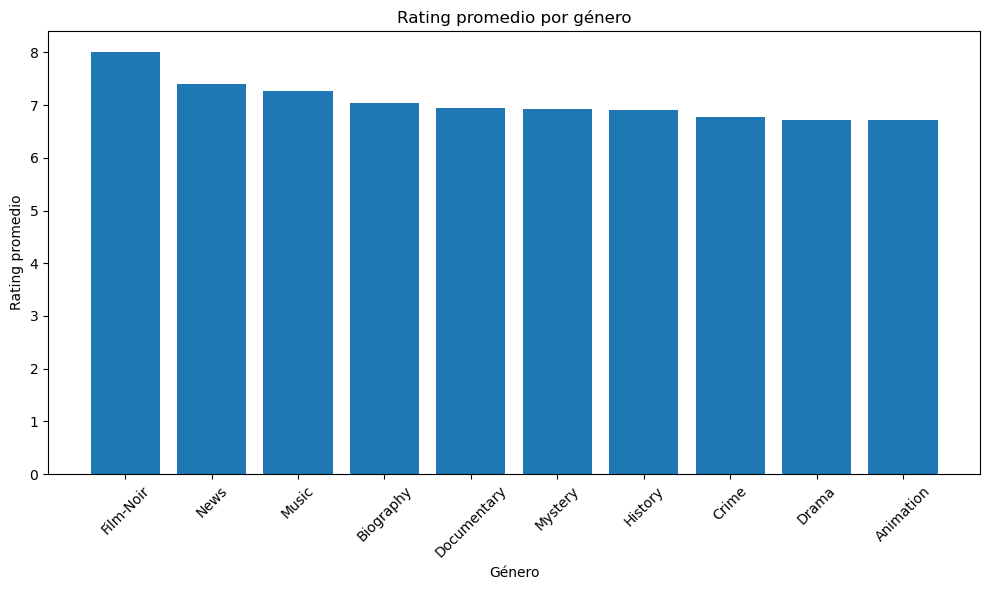

In [22]:
pdf1 = gold_genre_rating.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.bar(pdf1["genre"], pdf1["avg_rating"])
plt.xticks(rotation=45)
plt.title("Rating promedio por género")
plt.xlabel("Género")
plt.ylabel("Rating promedio")
plt.tight_layout()
plt.show()

### Interpretación del gráfico 1
El gráfico muestra los géneros con mejor rating promedio. Se observa que Film-Noir aparece como el género mejor valorado en este subconjunto, seguido de News y Music. Sin embargo, este resultado debe interpretarse junto con la cantidad de películas por género, ya que algunos grupos pueden tener pocos registros.

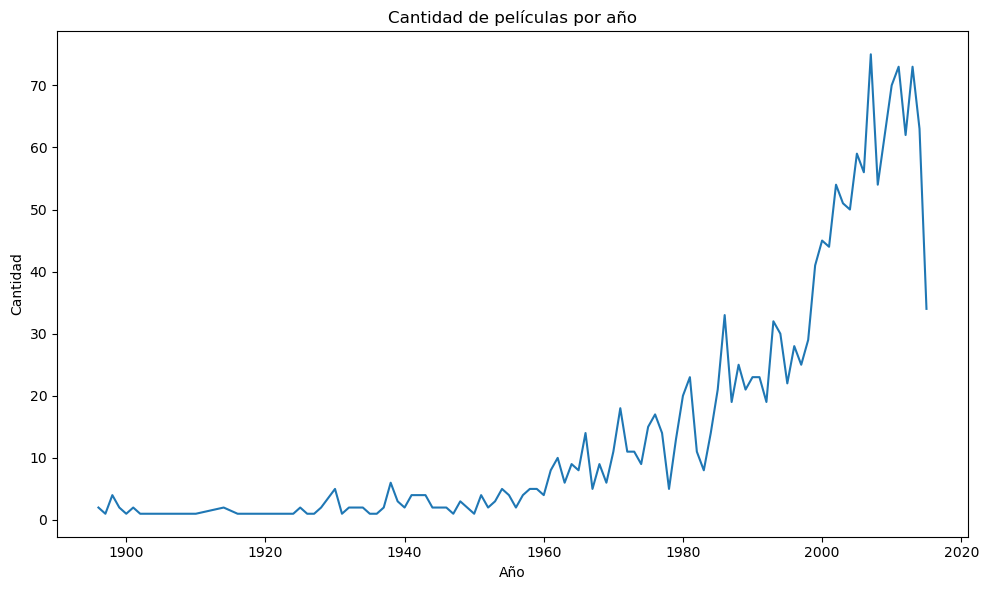

In [23]:
pdf2 = gold_movies_year.toPandas()

plt.figure(figsize=(10,6))
plt.plot(pdf2["year"], pdf2["total_movies"])
plt.title("Cantidad de películas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

### Interpretación del gráfico 2
La cantidad de películas por año crece claramente en las décadas más recientes. Esto sugiere que el dataset está mucho más concentrado en producciones contemporáneas que en películas antiguas, por lo que no representa de forma uniforme todos los periodos históricos.

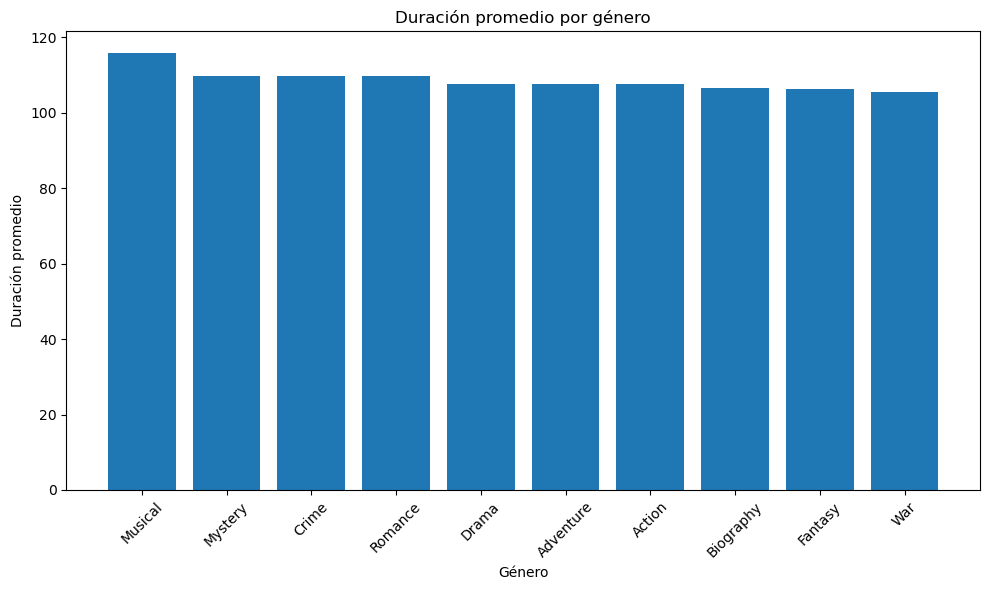

In [24]:
pdf3 = gold_runtime_genre.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.bar(pdf3["genre"], pdf3["avg_runtime"])
plt.xticks(rotation=45)
plt.title("Duración promedio por género")
plt.xlabel("Género")
plt.ylabel("Duración promedio")
plt.tight_layout()
plt.show()

### Interpretación del gráfico 3
La duración promedio por género muestra diferencias moderadas entre categorías. En este resultado, Musical aparece entre los géneros con mayor duración promedio, aunque varios géneros presentan valores relativamente cercanos.

## Comparación entre 1 y 4 particiones

Se compara el tiempo de ejecución de una transformación representativa utilizando primero una partición y luego cuatro particiones, con el fin de observar el efecto del paralelismo en Spark.

In [25]:
import time
from pyspark.sql.functions import avg, explode

start = time.time()
df1 = df_silver.repartition(1)
res1 = df1.withColumn("genre", explode(col("genres"))) \
          .groupBy("genre") \
          .agg(avg("runtime").alias("avg_runtime"))
res1.count()
time1 = time.time() - start

start = time.time()
df4 = df_silver.repartition(4)
res4 = df4.withColumn("genre", explode(col("genres"))) \
          .groupBy("genre") \
          .agg(avg("runtime").alias("avg_runtime"))
res4.count()
time4 = time.time() - start

print("Tiempo con 1 partición:", time1)
print("Tiempo con 4 particiones:", time4)
print("Particiones df1:", df1.rdd.getNumPartitions())
print("Particiones df4:", df4.rdd.getNumPartitions())

Tiempo con 1 partición: 0.2621347904205322
Tiempo con 4 particiones: 0.31523728370666504
Particiones df1: 1
Particiones df4: 4


Particionar un DataFrame en Spark significa dividir sus datos en bloques lógicos que pueden procesarse en paralelo. Esto influye en cómo Spark distribuye el trabajo entre tareas y en el costo de coordinación del procesamiento.

### Interpretación de la comparación
En esta prueba, el procesamiento con cuatro particiones resultó más lento que con una sola partición. Esto puede explicarse por el tamaño relativamente pequeño del dataset y por el costo adicional de coordinación que introduce el paralelismo. Por lo tanto, más particiones no implican automáticamente mejor rendimiento.

## Verificación de persistencia en MongoDB

Se verifica que las colecciones Silver y Gold fueron creadas correctamente en la base `video`.

In [26]:
%pip install pymongo

Note: you may need to restart the kernel to use updated packages.


In [27]:
from pymongo import MongoClient

client = MongoClient("mongodb://host.docker.internal:27017/")
db = client["video"]

print(db.list_collection_names())

for name in ["movieDetails", "movieDetails_silver", "gold_genre_rating", "gold_movies_year", "gold_runtime_genre"]:
    col_mongo = db[name]
    print(name, "->", col_mongo.count_documents({}))

['moviesScratch', 'gold_runtime_genre', 'movieDetailsXIX', 'gold_genre_rating', 'movieDetails', 'movieDetails_silver', 'gold_movies_year']
movieDetails -> 2299
movieDetails_silver -> 1711
gold_genre_rating -> 26
gold_movies_year -> 107
gold_runtime_genre -> 26


## Conclusiones

El pipeline ELT permitió transformar la colección original `movieDetails` en una estructura más adecuada para análisis, manteniendo intacto el origen y generando nuevas colecciones derivadas en MongoDB.

La colección Silver mejoró la consistencia de los datos utilizados en el análisis, al conservar únicamente registros con variables fundamentales disponibles. A partir de ella se construyeron tres colecciones Gold orientadas a responder preguntas concretas sobre calificaciones, distribución temporal y duración promedio por género.

Las visualizaciones facilitaron la interpretación de los resultados y mostraron patrones relevantes del dataset. Finalmente, la comparación entre una y cuatro particiones mostró que el paralelismo no siempre mejora el rendimiento cuando el volumen de datos es moderado.